Aim: Import files generated by buckygen and planarread, and transform the data into a tensor with iso(n) adjacency matrices

In [13]:
import numpy as np
import networkx as nx

In [2]:
path_database = "/Users/arturbille/Documents/forschung/buckygen&planarread/"

In [7]:
def import_Cn(n,oriented=True):
    m = int(n / 2 + 2)
    if oriented==True:
        path = path_database + "C" + str(n) + "_oriented_dual_read.txt"
    else:
        path = path_database + "C" + str(n) + "_unoriented_dual_read.txt"
    
    M = np.loadtxt(open(path,'rt').readlines()[:-1],usecols = (0,1,2,3,4,5))
    iso = int(M.shape[0]/m)
    A_tensor = np.zeros((m,m,iso))
    for i in range(iso):
        A = M[i*m:(i+1)*m,:]
        for j in range(m):
            for col in range(6):
                if A[j,col] != 0:
                    A_tensor[j,int(A[j,col]-1),i] = 1
    return A_tensor

In [8]:
n = 28
A_28_oriented = import_Cn(n,oriented=True)

In [10]:
np.shape(A_28_oriented)

(16, 16, 3)

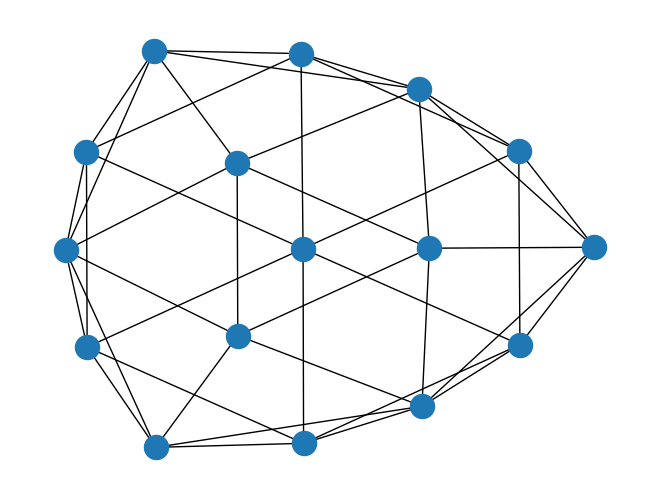

In [17]:
nx.draw(nx.Graph(A_28_oriented[:,:,2]))